In [118]:
import numpy as np
from matplotlib import pyplot as plt

In [119]:
path = r"results"

In [120]:
fopts = {"g1": -15, "g2": -0.0803553, "g3" : -0.990866, "g4": -30665.5, "g5" : 5126.4981,
         "g6": -6961.81381, "g7" : 24.3062091, "g8" : -0.011182, "g9": 680.6300573, "g10": 7049.330923,
         "g11" : 0.750455}

In [121]:
fnames = {"g1": "G01", "g2": "G02", "g3" : "G03", "g4": "G04", "g5" : "G05",
         "g6": "G06", "g7" : "G07", "g8" : "G08", "g9": "G09", "g10": "G10",
         "g11" : "G11"}

In [122]:
fun_name = "g11"

In [123]:
fname = fnames[fun_name]

In [124]:
fopt = fopts[fun_name]

In [125]:
def pad_array_with_zeros(arr,initial_value = np.nan, target_length=2000):
    current_length = len(arr)
    
    if current_length < target_length:
        padding_length = target_length - current_length
        
        padding = np.full((padding_length,) + arr.shape[1:], initial_value)
        
        arr = np.concatenate((padding, arr), axis=0)
    
    return arr

In [126]:
data1 = np.loadtxt(path+"/"+fun_name+"/"+fun_name+"_0.txt")
data2 = np.loadtxt(path+"/"+fun_name+"/"+fun_name+"_2.txt")
data3 = np.loadtxt(path+"/"+fun_name+"/"+fun_name+"_5.txt")
data4 = np.loadtxt(path+"/"+fun_name+"/"+fun_name+"_50.txt")
data5 = np.loadtxt(path+"/"+fun_name+"/"+fun_name+"_100.txt")

In [127]:
length = min([len(data1), len(data2), len(data3), len(data4), len(data5)])

In [128]:
data1 = pad_array_with_zeros(data1)
data2 = pad_array_with_zeros(data2)
data3 = pad_array_with_zeros(data3)
data4 = pad_array_with_zeros(data4)
data5 = pad_array_with_zeros(data5)

In [129]:
data_round = np.vstack((data1, data2, data3, data4, data5))
avg_round = np.average(data_round, axis = 0)
mean_values = np.mean(data_round, axis=0)
std_values = np.std(data_round, axis=0)

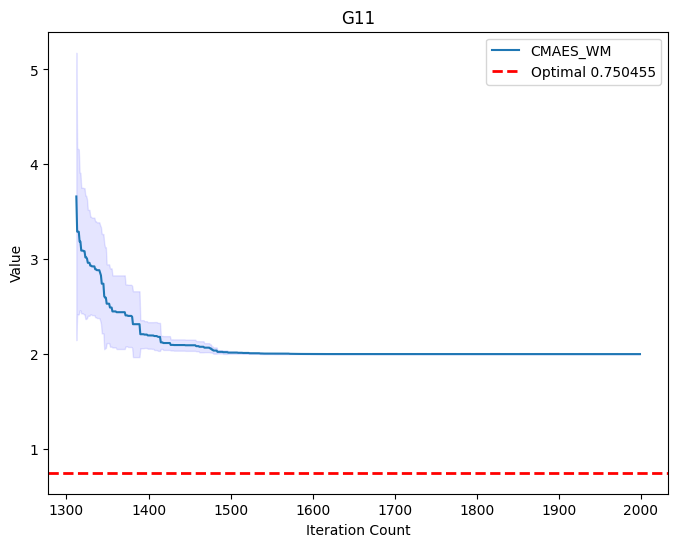

In [130]:
plt.figure(figsize=(8, 6))
plt.plot(mean_values, label='CMAES_WM')
plt.fill_between(range(len(mean_values)), 
                 mean_values - std_values, 
                 mean_values + std_values, 
                 color='blue', alpha=0.1)
plt.axhline(y= fopt, color="red", linestyle="--", linewidth=2, label="Optimal "+str(fopt))
plt.title(fname)
plt.xlabel('Iteration Count')
plt.ylabel('Value')
plt.legend()
plt.savefig("pics/cmaeswm_new_"+str(fname)+".png")
